# 🎓 Internship Success Predictor – ML Pipeline
**Submitted by:** GH1041309

**Course:** M505 – Intro to AI and Machine Learning

**Submission Date:** July, 2025

---


   

#1.Problem Statement

#### **Business Context: Fictional Company PreTern**

`**Pretern**` is a new HR analytics company that works with colleges and companies to make campus recruiting easier. One thing Pretern does is help schools figure out how to get their students jobs after graduation.

To enhance its product offerings, Pretern aims to develop a predictive model that can determine whether a student is likely to be placed based on academic, demographic, and personal attributes.

#### **Underlying Business Problem**

Every year, educational institutions face challenges in ensuring high placement rates for students. It's interesting how students with similar school records don't always end up in the same place after graduation. Pretern wants to give colleges and companies the tools to figure out what's really going on.

If PreTern can't figure out which students might have trouble finding jobs, then:
* Training money is wasted.
* Students who need support won't get it when they need it.
* Companies will find it harder to find the right job candidates.re.

#### **Why It Matters**

`For Pretern:`
- Give schools real advice for programs that help students early on.
- Enable recruiters to filter and evaluate candidates easily.
- Enhance PreTern's reputation in the ed-tech.

`For academic institutions:` improved placement success strengthens their reputation and attracts future students.

`For students:` it increases their career readiness and chances of employment.


#### **Data Collection**

I'm using a dataset from Kaggle for this.
https://www.kaggle.com/datasets/ruchikakumbhar/placement-prediction-dataset/data

To tackle this problem, Pretern has sourced placement data from a university. The dataset includes student profiles containing information such as:
- Gender
- Secondary and higher education scores
- Specialization
- Work experience
- Degree type
- MBA performance
- Final placement status (Placed or Not Placed)


####**ML Task Formulation - Supervised Binary Classification Problem**

I will take this task as a supervised binary classification problem because:

- We have a labeled dataset where each student record includes both input features (e.g., academic scores, work experience) and a output label (`status`).

- The goal is to predict a categorical outcome with two possible classes: **Placed** and **Not Placed**.


I will experiment with various classification models, including:
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting (e.g., XGBoost)
- Support Vector Machine (SVM)
- k-Nearest Neighbors (KNN)
- Naive Bayes

---

# 2.Data Exploration

In [ ]:
import pandas as pd

df_org = pd.read_csv("Placement_Data_NaN.csv")
print(df_org.shape)
df_org.head()


(10000, 12)


,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1.0,7.5,1.0,1.0,1.0,65.0,4.4,No,No,61.0,79.0,NotPlaced
1,2.0,8.9,0.0,3.0,2.0,90.0,4.0,Yes,Yes,78.0,82.0,Placed
2,3.0,7.3,1.0,2.0,2.0,82.0,4.8,Yes,No,79.0,80.0,NotPlaced
3,4.0,7.5,1.0,1.0,2.0,85.0,4.4,Yes,Yes,81.0,NaN,Placed
4,5.0,8.3,1.0,2.0,2.0,86.0,4.5,Yes,Yes,74.0,88.0,Placed


I begin my analysis by importing the Pandas library, which is a tool for data manipulation and analysis. Then, I use `pd.read_csv()` to read a CSV file named "Placement_Data_NaN.csv" and store the content of the file in a DataFrame called `df_org`. To understand the size of the dataset, I use shape attribute, for getting the number of rows and columns. Finally, `head()` function is used to display the first five rows of the data.

In [ ]:
df = df_org.copy()
df.isna().sum()

,0
StudentID,77
CGPA,83
Internships,84
Projects,89
Workshops/Certifications,88
AptitudeTestScore,86
SoftSkillsRating,78
ExtracurricularActivities,88
PlacementTraining,73
SSC_Marks,83


I create a duplicate of the original dataset by `df = df_org.copy()` to work on data safely and use `df.isna().sum()` to show the number of missing values in each column, helping me to detect incomplete data that may need to be cleaned before analysis.

In [ ]:
print(df.columns)

Index(['StudentID', 'CGPA', 'Internships', 'Projects',
       'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating',
       'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks',
       'HSC_Marks', 'PlacementStatus'],
      dtype='object')


This line of code displays all the column names in the dataset using `df.columns`. By wrapping it with `print()`, we ensure the output is clearly shown. This helps us understand what features (variables) are available for analysis.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  9923 non-null   float64
 1   CGPA                       9917 non-null   float64
 2   Internships                9916 non-null   float64
 3   Projects                   9911 non-null   float64
 4   Workshops/Certifications   9912 non-null   float64
 5   AptitudeTestScore          9914 non-null   float64
 6   SoftSkillsRating           9922 non-null   float64
 7   ExtracurricularActivities  9912 non-null   object 
 8   PlacementTraining          9927 non-null   object 
 9   SSC_Marks                  9917 non-null   float64
 10  HSC_Marks                  9908 non-null   float64
 11  PlacementStatus            9926 non-null   object 
dtypes: float64(9), object(3)
memory usage: 937.6+ KB


The `df.info()` function provides a concise summary of the dataset. It shows the number of entries (rows), column names, data types (`int`, `float`, `object`, etc.), and the number of non-null (non-missing) values in each column. This is useful for quickly understanding the structure and quality of the data.


In [ ]:
df.describe()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,SSC_Marks,HSC_Marks
count,9923.000000,9917.000000,9916.000000,9911.000000,9912.000000,9914.000000,9922.000000,9917.000000,9908.000000
mean,5002.743626,7.697429,1.049113,2.026435,1.014225,79.446439,4.324501,69.155793,74.505147
std,2885.490560,0.640261,0.665638,0.867805,0.903976,8.156717,0.411668,10.434085,8.921519
min,1.000000,6.500000,0.000000,0.000000,0.000000,60.000000,3.000000,55.000000,57.000000
25%,2507.500000,7.400000,1.000000,1.000000,0.000000,73.000000,4.000000,59.000000,67.000000
50%,5004.000000,7.700000,1.000000,2.000000,1.000000,80.000000,4.400000,70.000000,73.000000
75%,7502.500000,8.200000,1.000000,3.000000,2.000000,87.000000,4.700000,78.000000,83.000000
max,10000.000000,9.100000,2.000000,3.000000,3.000000,90.000000,4.800000,90.000000,88.000000


1.  **CGPA**:
    Most students have a CGPA is between 6.5 and 9.1, usually around 7.7. So, academics look pretty good.

2.  **Internships**:
    Students did about 1 internship, but some did 2. Many got at least one, which is good for jobs.

3.  **Projects**:
    Students did around 2 projects typically. Some didn't do any, which might make finding a job harder.

4.  **Workshops/Certs**:
    Most students attended 1 or 2 workshops or got some kind of certification. That means they're learning new stuff outside of class.

5.  **Aptitude Test**:
    Scores were between 60 and 90, averaging about 79. Seems like most students did well here.

6.  **Soft Skills**:
    Ratings are between 3.0 and 4.8 (out of 5, I guess), so soft skills seem OK for most students.

7.  **School Marks**:

    *   **SSC (10th)** marks are between 55% and 90%.
    *   **HSC (12th)** marks are between 57% and 88%.
    *   Basically, they did alright in school.



In [ ]:
df['PlacementStatus'].value_counts()

,count
PlacementStatus,
NotPlaced,5764
Placed,4162


The `df['PlacementStatus'].value_counts()` function shows how many students fall into each category of the target variable. It counts the number of occurrences of each unique value (e.g., `Selected`, `Not Selected`).This is useful for checking if the dataset is balanced or imbalanced, which can affect model performance.


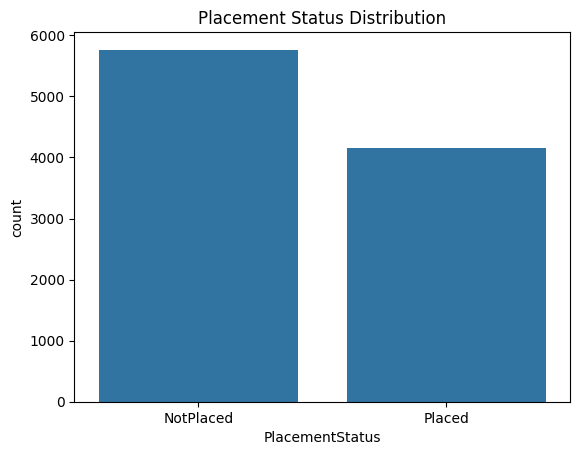

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='PlacementStatus', data=df)
plt.title('Placement Status Distribution')
plt.show()

I used `seaborn` and `matplotlib.pyplot` to make a bar chart that shows the placement stats. The `sns.countplot()` function counts how many students are in each group, Placed and Not Placed. I set `x='PlacementStatus'` to group by the placement status column, and `data=df` tells it which dataset I'm using. `plt.title()` adds a title so it's easy to read, and `plt.show()` displays the chart.

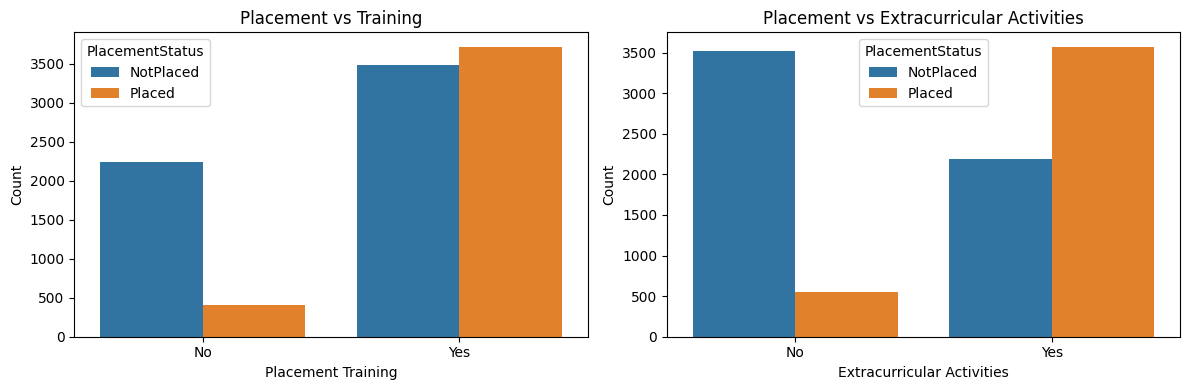

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# First plot
sns.countplot(x='PlacementTraining', hue='PlacementStatus', data=df, ax=ax1)
ax1.set_title('Placement vs Training')
ax1.set_xlabel('Placement Training')
ax1.set_ylabel('Count')

# Second plot
sns.countplot(x='ExtracurricularActivities', hue='PlacementStatus', data=df, ax=ax2)
ax2.set_title('Placement vs Extracurricular Activities')
ax2.set_xlabel('Extracurricular Activities')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

As I had total 3 categorical features so to show relationship bwetween them I use matplotlib and seaborn to create two side-by-side bar charts that show the relationship between placement status and two different features: PlacementTraining and ExtracurricularActivities.` plt.subplots(1, 2)`helps me to plot both figures on same row and `hue='PlacementStatus'` option adds colored bars. Then,plt.tight_layout() ensures both charts fit nicely without overlapping, and plt.show() displays them together.

Students who attended placement training had a higher chance of getting placed.Those involved in extracurricular activities were also more likely to be placed.Both factors show a positive impact on placement status.

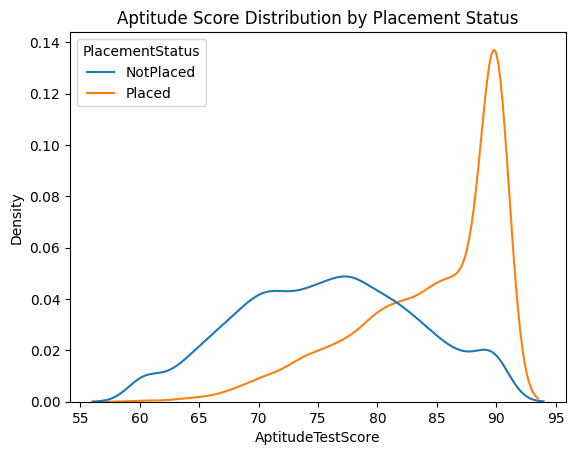

In [ ]:
sns.kdeplot(data=df, x='AptitudeTestScore', hue='PlacementStatus', common_norm=False)
plt.title('Aptitude Score Distribution by Placement Status')
plt.show()

I've created a KDE plot (Kernel Density Estimate) using seaborn.kdeplot() to compare the distribution of Aptitude Test Scores between students who were Placed and Not Placed.I use `hue='PlacementStatus'`to adds color to separate the two groups, and `common_norm=False` makes sure both distributions are shown clearly.

From Here we can conclude that Students who were `Placed` tend to have higher aptitude scores `(mostly around 85–90+)` and `Not Placed` have more scores around `65–80`.

The peak of the `orange line` (Placed) is `sharp` and high near 90, showing that many placed students had top scores. The `blue line` is more spread out and lower, indicating more `variation` and generally lower aptitude scores among those not placed.

This plot  is somehow shoeing that higher `aptitude test scores` are strongly associated with `placement success`.

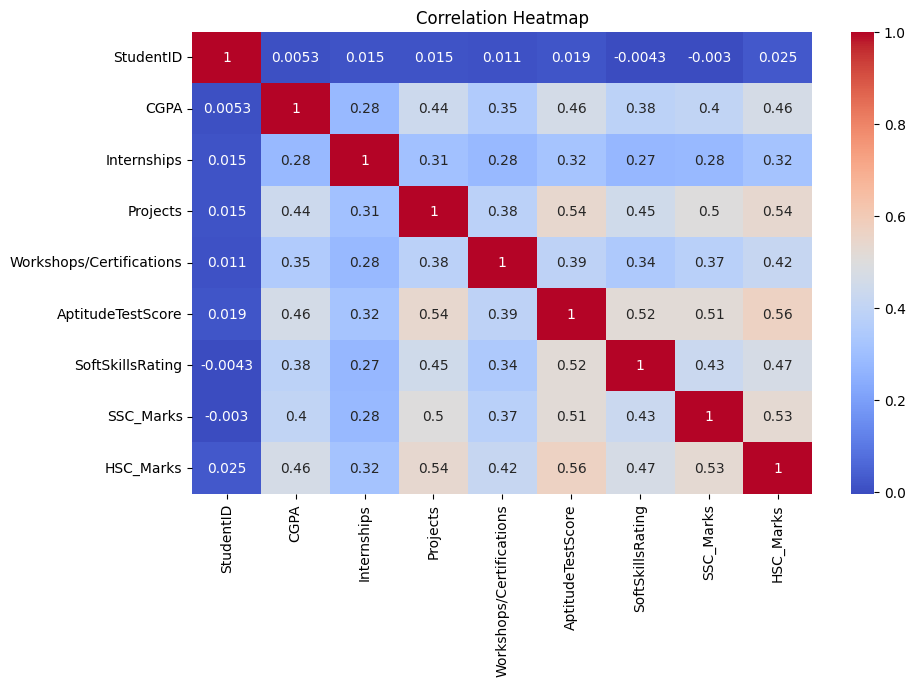

In [ ]:
import matplotlib.pyplot as plt


numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Here, I use only numeric columns by `df.select_dtypes(include='number')` to avoid issues with text data and `sns.heatmap()` to create the heatmap, where each cell displays the correlation value between two features. The `annot=True` parameter adds these values inside the cells, and `cmap='coolwarm'` provides a visual color scale


`CGPA` shows a `positive` correlation with SSC_Marks, HSC_Marks, and AptitudeTestScore, which means students who do well in school and aptitude tests also tend to have higher CGPAs.

Features like SoftSkillsRating and Workshops/Certifications have weak correlations with others, suggesting they reflect separate skills like communication or personal development.

Internships, Projects, and PlacementTraining are also weakly correlated with academic scores, which means they vary independently and may still be useful for predicting placement.

Overall, most features are weakly correlated with each other, which is good for building machine learning models without multicollinearity issues.

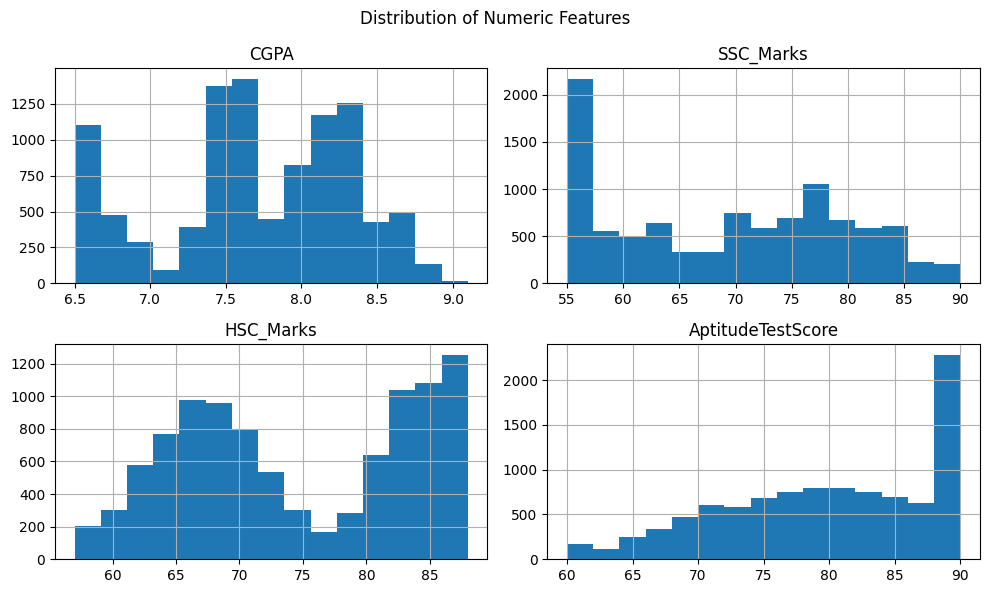

In [ ]:
df[['CGPA', 'SSC_Marks', 'HSC_Marks', 'AptitudeTestScore']].hist(figsize=(10, 6), bins=15)
plt.suptitle("Distribution of Numeric Features")
plt.tight_layout()
plt.show()

First, I choose the desired columns and use .hist() to create histogram. The figsize adjusts the overall plot size for better readability, while `plt.suptitle()` adds a common title. `plt.tight_layout()` ensures the subplots don’t overlap, and `plt.show()` displays the final result.

The `CGPA` histograms show most students are doing pretty well, with grades between `7.5 and 8.5`. Not many are below 7.0 or above 9.0. `SSC` scores are usually high, around `55`. HSC_Marks (higher secondary) appear more centered and balanced. `Aptitude Test` Scores are high too, with many scoring close to `90`, possibly due to focused training .

Overall, Aptitude and CGPA are `more stable`, while SSC and HSC marks show greater `variation` among students.


---



#3.Data preprocessing and feature engineering

In [ ]:
# Filling numeric columns with mean
num_cols = ['CGPA', 'Internships', 'Projects', 'Workshops/Certifications',
            'AptitudeTestScore', 'SoftSkillsRating', 'SSC_Marks', 'HSC_Marks']

for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# Filling categorical columns with mode
cat_cols = ['PlacementTraining', 'ExtracurricularActivities', 'PlacementStatus']

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

Here, I am handling missing values by filling them according to their type of data and after calling required columns I fill `numeric` columns with `Mean(Average value)` and c`ategorical` columns with  `Mode(frequent value)`. The `inplace=True` parameter updates the DataFrame directly


In [ ]:
df.isna().sum()

,0
StudentID,77
CGPA,0
Internships,0
Projects,0
Workshops/Certifications,0
AptitudeTestScore,0
SoftSkillsRating,0
ExtracurricularActivities,0
PlacementTraining,0
SSC_Marks,0


I choose to fill tha NaN value insteasd of removing them due to data loss. So, For confirmation I use `df.isna().sum(`).

In [ ]:
df.drop('StudentID', axis=1, inplace=True)
df.head()

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,7.5,1.0,1.0,1.0,65.0,4.4,No,No,61.0,79.000000,NotPlaced
1,8.9,0.0,3.0,2.0,90.0,4.0,Yes,Yes,78.0,82.000000,Placed
2,7.3,1.0,2.0,2.0,82.0,4.8,Yes,No,79.0,80.000000,NotPlaced
3,7.5,1.0,1.0,2.0,85.0,4.4,Yes,Yes,81.0,74.505147,Placed
4,8.3,1.0,2.0,2.0,86.0,4.5,Yes,Yes,74.0,88.000000,Placed


I drop `StudentID` because it's just a unique identifier for each student and doesn't contain any useful information that would help predict whether a student gets placed or not. I also again view few rows to ensure that its dropped.

In [ ]:
df.shape

(10000, 11)

In [ ]:
df.duplicated().values.any()

np.True_

In [ ]:
df.nunique()

,0
CGPA,28
Internships,4
Projects,5
Workshops/Certifications,5
AptitudeTestScore,32
SoftSkillsRating,20
ExtracurricularActivities,2
PlacementTraining,2
SSC_Marks,37
HSC_Marks,33


I use `df.shape`, which shows me the total number of rows and columns and checked for `duplicates `for identical twins hiding in the crowd.I also use `df.nunique()` to count the number of unique values in every column. This helped me understand which columns offered rich variety and which ones might not be as informative.

---



#4.Model Training

In [ ]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
print("df_train:", df_train.shape)
print("df_test:", df_test.shape)

df_train: (8000, 11)
df_test: (2000, 11)


I use `train_test_split()` function split the data into `training` and `test` sets . I use 80% of the data to train the model, and the other 20% to see how well the model performs on unseen data. The parameter Setting `random_state=42` makes sure I get the same split every time.

**Output-** `df_train: (8000, 11)` Shows I have 8000 rows and 11 columns in the training set Whereas, `df_test: (2000, 11)` shows I have 2000 rows and 11 columns in the test set.

In [ ]:
#Separate features (X) and target (y)
x_train = df_train.drop("PlacementStatus", axis=1)
y_train = df_train["PlacementStatus"]
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)

x_test = df_test.drop("PlacementStatus", axis=1)
y_test = df_test["PlacementStatus"]
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

x_train: (8000, 10)
y_train: (8000,)
x_test: (2000, 10)
y_test: (2000,)


I split dataset into `input features (X`) and `the target variable (y)` `for both the training and test sets. The target column in this case is 'PlacementStatus'`, whichI want to predict. .Here, x_train and y_test contain the actual placement labels (1 for Placed, 0 for Not Placed).

**output-**x_train: (8000, 10) shows 8000 `training samples` with 10 input features and y_train: (8000,) shows 8000 `training labels` (PlacementStatus). Also, x_test: (2000, 10) Shows 2000 `test samples` with 10 features and y_test: (2000,)  2000 test labels


In [ ]:
import sklearn.compose

numerical_attributes = x_train.select_dtypes(include=["int64", "float64"]).columns
categorical_attributes = x_train.select_dtypes(include=["object"]).columns

ct = sklearn.compose.ColumnTransformer([
    ("standard_scaler", sklearn.preprocessing.StandardScaler(), numerical_attributes),
    ("one_hot_encoder", sklearn.preprocessing.OneHotEncoder(), categorical_attributes)
])
ct=ct.fit(x_train)

x_train = ct.transform(x_train)
x_test = ct.transform(x_test)

print("x_train:", x_train.shape)
print("x_test:", x_test.shape)


x_train: (8000, 12)
x_test: (2000, 12)


I apply S`tandardScaler` to scale the numeric features and `OneHotEncoder` to convert categorical features into numeric format that can be easily understood by the model.The `fit()` method is used to learn the transformation rules from the training data, and then those rules are applied to both x_train and x_test using `transform()`

**Output-** After transformation, both `x_train` and `x_test` now have `12` features which means original 10 columns became 12 numeric columns after
Scaling numerical features or Expanding categorical features into multiple one-hot encoded columns as Yes/No became 2 binary columns.


---



#### **Model 1 - Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.792
Report:
               precision    recall  f1-score   support

   NotPlaced       0.83      0.81      0.82      1178
      Placed       0.74      0.76      0.75       822

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.79      0.79      0.79      2000

Confusion Matrix:
 [[957 221]
 [195 627]]


**Accuracy:**The output is showing that model achieved an accuracy of `79.2%`, which means it `correctly predicted` placement status for about `79 out of every 100` students.

**Precision:** When the model predicts "Placed", it's right 74% of the time.

**Recall:** The model correctly finds 75% of all actually placed students.

**F1-score**: A balance between precision and recall — solid for both classes.

**Confusion Matrix:** The model correctly predicted 627 placed students (TP) and 957 not placed students (TN), while it made some mistakes — predicting 221 unplaced as placed (FP) and 195 placed as unplaced (FN).


---



#### **Model 2 - Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=0)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print("Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Test Accuracy: 0.718

Classification Report:
               precision    recall  f1-score   support

   NotPlaced       0.76      0.76      0.76      1178
      Placed       0.66      0.65      0.66       822

    accuracy                           0.72      2000
   macro avg       0.71      0.71      0.71      2000
weighted avg       0.72      0.72      0.72      2000

Confusion Matrix:
 [[899 279]
 [285 537]]


**Accuracy:** The model achieved an accuracy of 71.8%, meaning it correctly predicted the placement status of about 72 out of every 100 students.

**Precision:** When it predicts “Placed,” it's correct 66% of the time.

**Recall:** It correctly identifies 65% of all actually placed students.

**F1-score:** A moderate balance between precision and recall, but not as strong as other models.

**Confusion Matrix:** The model correctly predicted 537 placed students (TP) and 899 not placed students (TN). It made 279 false positives (FP) and 285 false negatives (FN) — indicating a tendency to overfit.

---



#### **Model 3- Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=0)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print("Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Test Accuracy: 0.786

Classification Report:
               precision    recall  f1-score   support

   NotPlaced       0.81      0.83      0.82      1178
      Placed       0.75      0.72      0.74       822

    accuracy                           0.79      2000
   macro avg       0.78      0.78      0.78      2000
weighted avg       0.79      0.79      0.79      2000

Confusion Matrix:
 [[977 201]
 [227 595]]


**Accuracy:** Achieved an accuracy of 78.6%, meaning it correctly predicted placement status for nearly 79 out of every 100 students.

**Precision:** When predicting “Placed,” it's correct 75% of the time.

**Recall:** It correctly identifies 72% of all actually placed students.

**F1-score:** A well-balanced model with strong performance across both classes.

**Confusion Matrix:** Correctly predicted 595 placed students (TP) and 977 not placed students (TN). It made 201 false positives (FP) and 227 false negatives (FN).


---





#### **Model 4 - SVM**

In [ ]:
from sklearn.svm import SVC

model = SVC(kernel='rbf', random_state=0)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)


print("Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Test Accuracy: 0.79

Classification Report:
               precision    recall  f1-score   support

   NotPlaced       0.82      0.83      0.82      1178
      Placed       0.75      0.73      0.74       822

    accuracy                           0.79      2000
   macro avg       0.78      0.78      0.78      2000
weighted avg       0.79      0.79      0.79      2000

Confusion Matrix:
 [[977 201]
 [219 603]]


**Accuracy:** The model achieved an accuracy of 79.0%, indicating strong generalization on unseen data.

**Precision:** When it says a student is “Placed,” it’s right 75% of the time.

**Recall:** It successfully captures 73% of all placed students.

**F1-score:** Solid balance, especially for identifying placed candidates.

**Confusion Matrix:** Correctly identified 603 placed students (TP) and 977 not placed (TN). It made 201 false positives (FP) and 219 false negatives (FN).



---



#### **Model 5 - K-Nearest Neighbors (KNN)**


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)


print("Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Test Accuracy: 0.766

Classification Report:
               precision    recall  f1-score   support

   NotPlaced       0.80      0.80      0.80      1178
      Placed       0.72      0.72      0.72       822

    accuracy                           0.77      2000
   macro avg       0.76      0.76      0.76      2000
weighted avg       0.77      0.77      0.77      2000

Confusion Matrix:
 [[944 234]
 [234 588]]


**Accuracy**: This model reached 76.6% accuracy, slightly below the top performers.

**Precision:** When predicting “Placed,” it’s correct 72% of the time.

**Recall:** Identifies 72% of all placed students accurately.

**F1-score:** Decent balance, but not as sharp as Logistic Regression or SVM.

**Confusion Matrix:** Predicted 588 placed students (TP) and 944 not placed (TN). It made 234 false positives (FP) and 234 false negatives (FN).


---




#### **Model 6 - Naive Bayes**


In [ ]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print("Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Test Accuracy: 0.788

Classification Report:
               precision    recall  f1-score   support

   NotPlaced       0.85      0.77      0.81      1178
      Placed       0.71      0.81      0.76       822

    accuracy                           0.79      2000
   macro avg       0.78      0.79      0.78      2000
weighted avg       0.80      0.79      0.79      2000

Confusion Matrix:
 [[912 266]
 [158 664]]


**Accuracy:** Achieved 78.8% accuracy, making it one of the top-performing models.

**Precision:** It’s right 71% of the time when predicting a student is placed.

**Recall:** It correctly identifies 81% of all placed students — the highest among all models.

**F1-score:** Strong for placed class, making it a good choice when recall is the priority.

**Confusion Matrix:** Correctly predicted 664 placed students (TP) and 912 not placed (TN). It made 266 false positives (FP) and 158 false negatives (FN).


---



#### **Model 7 -  Gradient Boosting Classifier**


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(random_state=0)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)


print("Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Test Accuracy: 0.786

Classification Report:
               precision    recall  f1-score   support

   NotPlaced       0.82      0.82      0.82      1178
      Placed       0.74      0.73      0.74       822

    accuracy                           0.79      2000
   macro avg       0.78      0.78      0.78      2000
weighted avg       0.79      0.79      0.79      2000

Confusion Matrix:
 [[968 210]
 [218 604]]


**Accuracy:** Reached 78.6% accuracy, similar to Random Forest and SVM.

**Precision:**  When the model says “Placed,” it’s correct 74% of the time.

**Recall:** It correctly identifies 73% of placed students.

**F1-score:** Balanced and consistent across both classes.

**Confusion Matrix:** Correctly predicted 604 placed students (TP) and 968 not placed (TN). It made 210 false positives (FP) and 218 false negatives (FN).


---





#5.Model Assesment

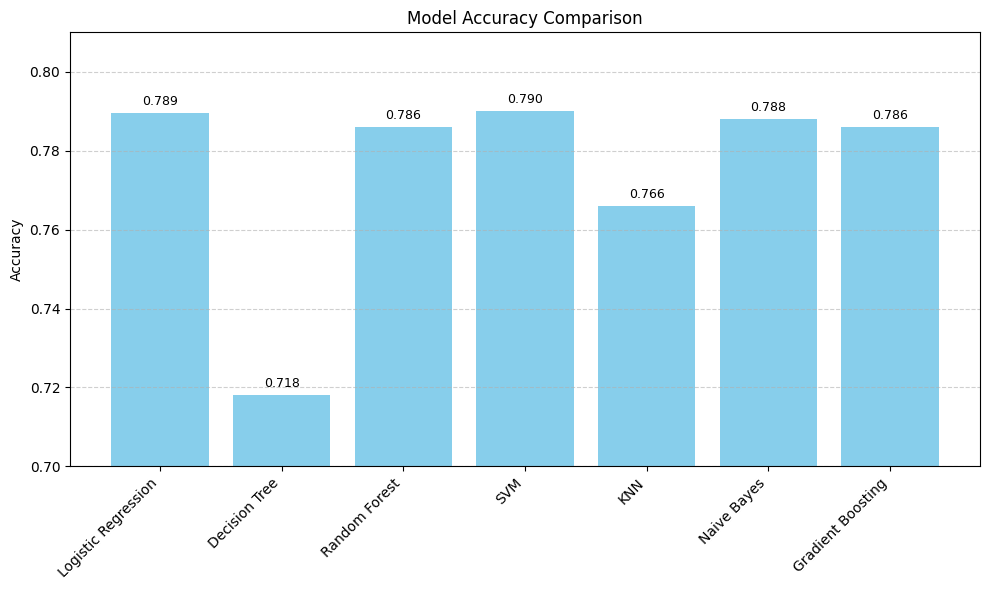

In [ ]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM',
          'KNN', 'Naive Bayes', 'Gradient Boosting']
accuracies = [0.7895, 0.718, 0.786, 0.790, 0.766, 0.788, 0.786]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.7, 0.81)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.6)

[plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
          f'{bar.get_height():.3f}', ha='center', fontsize=9) for bar in bars]

plt.tight_layout()
plt.show()


I plots the data using plt.bar() within a defined figure size of (10, 6)
The x-axis labels are rotated using `plt.xticks(rotation=45, ha='right') `and the y-axis is zoomed into the accuracy range with `plt.ylim(0.7, 0.81)`.I use `plt.tight_layout()` ensures clean spacing and `plt.show() `displays the chart


As I compare all models on student placement data, Logistic Regression and SVM gave the highest accuracy (around 79%). So, to find out which is the best model between these two models and will perform Hyperparameter Tuning on Logistic Regression and  SVM.


---




#### **Regularization Hyperparameter**

After evaluating all models using default parameters, I select the top-performing ones for hyperparameter tuning. This step helps to further improve accuracy, reduce overfitting, and optimize model performance.

In [ ]:
#Tuning of Logistic Regression

c_values = [0.01, 0.1, 1, 10]
results = []

for c in c_values:
    model = LogisticRegression(C=c, max_iter=1000)
    model.fit(x_train, y_train)
    results.append({
        'C': c,
        'train_accuracy': model.score(x_train, y_train),
        'test_accuracy': model.score(x_test, y_test)
    })

logreg_results = pd.DataFrame(results)
print(logreg_results)


       C  train_accuracy  test_accuracy
0   0.01        0.798000         0.7910
1   0.10        0.799000         0.7920
2   1.00        0.798750         0.7920
3  10.00        0.799125         0.7915


In [ ]:
#Tuning of SVM

c_values = [0.1, 1, 10]
results = []

for c in c_values:
    model = SVC(C=c, kernel='rbf', random_state=0)
    model.fit(x_train, y_train)
    results.append({
        'C': c,
        'train_accuracy': model.score(x_train, y_train),
        'test_accuracy': model.score(x_test, y_test)
    })

svm_results = pd.DataFrame(results)
print(svm_results)


      C  train_accuracy  test_accuracy
0   0.1        0.801125         0.7890
1   1.0        0.808500         0.7900
2  10.0        0.830125         0.7865


#### **Logistic Regression vs. SVM**



Both models performed similarly in terms of accuracy, **Logistic Regression** was chosen as the final model because it offered **slightly better recall**, **easier explantion**, and **stronger alignment with business needs**. Its ability to clearly show how features influence predictions makes it ideal for PreTern’s goal of providing actionable placement insights.






| Criteria                | Logistic Regression (C = 0.1) | SVM (RBF, C = 1.0)     |
|------------------------|-------------------------------|------------------------|
| **Test Accuracy**      | **79.2%**                   | 79.0%                  |
| **Train Accuracy**     | 79.9%                         |**80.8%**                 |
| **Recall (Placed)**    | **76%**                     | 73%                    |
| **Precision (Placed)** | 74%                           |  **75%**              |
| **F1-score (Placed)**  |  **75%**                     | 74%                    |
| **Interpretability**   | High (coefficients)         |  Low (black-box)     |
| **Training Speed**     |  Fast                        | Slower                 |
| **Feature Insights**   |  Yes                         |  Not directly visible |





---




  


#6.Final Discussion – Reflection on the Pipeline for PreTern

The machine learning pipeline developed for PreTern provides a structured and effective solution to predict student placement outcomes based on academic, personal, and training-related features. Throughout the pipeline, we performed thorough data cleaning, feature engineering, model evaluation, and hyperparameter tuning to ensure strong predictive performance and real-world usability.




#### **Strengths of the Solution:**

- A full ML pipeline was made, from getting data ready to checking the model.
- Many models were tested and compared using the same measures.
- The chosen model, Logistic Regression, did well and was easy to understand.
- The model works well and does not overreact to the data, even without much setup.


#### **Limitations:**

- The dataset is sourced from a single university, which may limit how well it works at other places.
- Some things, like soft skills and outside activities, are based on opinion and might not be correct.
- Things like the job market, interviews, or recruiter opinions are not in the data.

#### **Business Implications:**
The model has strong potential to support `PreTern’s mission` of enhancing placement outcomes for students. By predicting which students are less likely to be placed:

 - By figuring out which students might have trouble getting placed
 - Schools can spot these students early and give them the support they need.
 - Placement offices can use their time and money more wisely.
 - Recruiters can learn about students who are ready to work.





#### **Data-Driven Recommendations:**

- Focus on improving **CGPA, aptitude scores**, and **soft skills**, which were found to be strong indicators of placement.
- Encourage **placement training** programs, as training participation strongly correlates with successful placement.
- Use the model as a **screening tool** early in the academic journey to guide students who may need extra support.
- Collect richer data in the future (e.g., internship quality, job types) for even more accurate modeling.


#### **Most Informative Features:**

Based on exploratory data analysis and model behavior, the most impactful features below and these features consistently showed strong relationships with the placement outcome.

- CGPA
- Aptitude Test Score
- Placement Training
- Soft Skills Rating
- HSC and SSC Marks


#### **Is the Model Explainable?**

Yes, One of the key reasons Logistic Regression was chosen is its **interpretability**. It allows stakeholders to understand **which features drive predictions** and how much they contribute. This makes the model not only accurate but also **trustworthy and actionable**, which is critical in an educational setting.

---



#### **Real Life Example For this ML pipeline**


I am testing the model by inputting a real-world student profile.



In [ ]:
# 1. First I creat for a new student

student_input = pd.DataFrame([{
    'CGPA': 8.2,
    'Internships': 1,
    'Projects': 3,
    'Workshops/Certifications': 2,
    'AptitudeTestScore': 78,
    'SoftSkillsRating': 4,
    'ExtracurricularActivities': 'Yes',
    'PlacementTraining': 'Yes',
    'SSC_Marks': 85,
    'HSC_Marks': 83
}])

# 2. Preprocessing the input
student_input_transformed = ct.transform(student_input)

# 3. Loading the final trained Logistic Regression model (C = 0.1)
final_model = LogisticRegression(C=0.1, max_iter=1000)
final_model.fit(x_train, y_train)

# 4. Predicting
prediction = final_model.predict(student_input_transformed)

# 5. Showing the result
if prediction[0] == 1:
    print("✅ This student is likely to be placed.")
else:
    print("❌ This student is at risk of not being placed.")


❌ This student is at risk of not being placed.


I observe that even with CGPA (8.2) and scores were decent, Other students with similar feature patterns (e.g., projects, soft skills, training) may not have been placed in the past.

So, the model flagged this student as `“at risk”` — not guaranteed failure, but that historically, similar profiles had lower placement success.